# Analisis Perbandingan Performa Model Convolutional Neural Network (CNN), Multilayer Perceptron (MLP), dan CNN-MLP pada Klasifikasi Produk Fashion

Kelompok 13: 2024D


* Salma Latifa Kamil (24031554089)
* Audy Alycia (24031554179)


# Load Library

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
import requests
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import as_completed

import tensorflow as tf
from tensorflow.keras.models import load_model, Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report

# Download Dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("sawkumar/fashion-datasets")
path

Using Colab cache for faster access to the 'fashion-datasets' dataset.


'/kaggle/input/fashion-datasets'

In [ ]:
os.listdir(path)

['images.csv', 'styles.csv']

# Load Dataset

In [ ]:
csv_images = os.path.join(path, "images.csv")
df_images = pd.read_csv(csv_images, engine="python", on_bad_lines="skip")

df_images.shape
df_images.head()

,filename,link
0,15970.jpg,http://assets.myntassets.com/v1/images/style/p...
1,39386.jpg,http://assets.myntassets.com/v1/images/style/p...
2,59263.jpg,http://assets.myntassets.com/v1/images/style/p...
3,21379.jpg,http://assets.myntassets.com/v1/images/style/p...
4,53759.jpg,http://assets.myntassets.com/v1/images/style/p...


In [ ]:
csv_style = os.path.join(path, "styles.csv")
df_style = pd.read_csv(csv_style, engine="python", on_bad_lines="skip")

df_style.shape
df_style.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


# Cek Kolom dan Missing Value

In [ ]:
df_style.isna().sum()

,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,15
season,21
year,1
usage,317
productDisplayName,7


In [ ]:
df_style = df_style.dropna()

In [ ]:
df_style.isna().sum()

,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,0
season,0
year,0
usage,0
productDisplayName,0


In [ ]:
df_style.duplicated().sum()

np.int64(0)

In [ ]:
df_images.duplicated().sum()

np.int64(0)

# Membuat Nama File dan Merge Dataset

In [ ]:
df_style['filename'] = (df_style['id'].astype(str) + ".jpg")

merged = df_style.merge(df_images, on='filename', how='inner')

print("styles:", len(df_style))
print("images:", len(df_images))
print("merged", len(merged))

styles: 44077
images: 44446
merged 44077


In [ ]:
print(merged['articleType'].value_counts().head(30))

articleType
Tshirts                  7066
Shirts                   3214
Casual Shoes             2845
Watches                  2542
Sports Shoes             2016
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   928
Flip Flops                914
Sandals                   895
Briefs                    847
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     603
Jeans                     603
Shorts                    547
Trousers                  530
Flats                     500
Bra                       477
Dresses                   464
Sarees                    427
Earrings                  416
Deodorant                 347
Track Pants               304
Clutches                  288
Name: count, dtype: int64


In [ ]:
print("Banyak kelas:", merged['articleType'].nunique())

Banyak kelas: 142


# Ambil Top20 ArticleType

In [ ]:
top20 = (
    merged['articleType']
    .value_counts()
    .head(20)
    .index
)

top20_df = merged[
    merged['articleType'].isin(top20)
].copy()

print("Jumlah data:", len(top20_df))

print(top20_df['articleType'].value_counts())

Jumlah data: 33094
articleType
Tshirts                  7066
Shirts                   3214
Casual Shoes             2845
Watches                  2542
Sports Shoes             2016
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   928
Flip Flops                914
Sandals                   895
Briefs                    847
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Jeans                     603
Perfume and Body Mist     603
Name: count, dtype: int64


## Sampling 15% per Kelas

In [ ]:
sample_df = (
    top20_df
    .groupby('articleType', group_keys=False)
    .apply(
        lambda x: x.sample(
            frac=0.15,
            random_state=42
        )
    )
    .reset_index(drop=True)
)

/tmp/ipykernel_1653/3500179470.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [ ]:
print(sample_df.shape)
print(sample_df['articleType'].value_counts())

(4963, 12)
articleType
Tshirts                  1060
Shirts                    482
Casual Shoes              427
Watches                   381
Sports Shoes              302
Kurtas                    277
Tops                      264
Handbags                  264
Heels                     198
Sunglasses                161
Wallets                   139
Flip Flops                137
Sandals                   134
Briefs                    127
Belts                     122
Backpacks                 109
Socks                     103
Formal Shoes               96
Perfume and Body Mist      90
Jeans                      90
Name: count, dtype: int64


## Save csv

In [ ]:
sample_df.to_csv("fashion_top20_15percent.csv", index=False)

In [ ]:
print(len(sample_df))

4963


# EDA

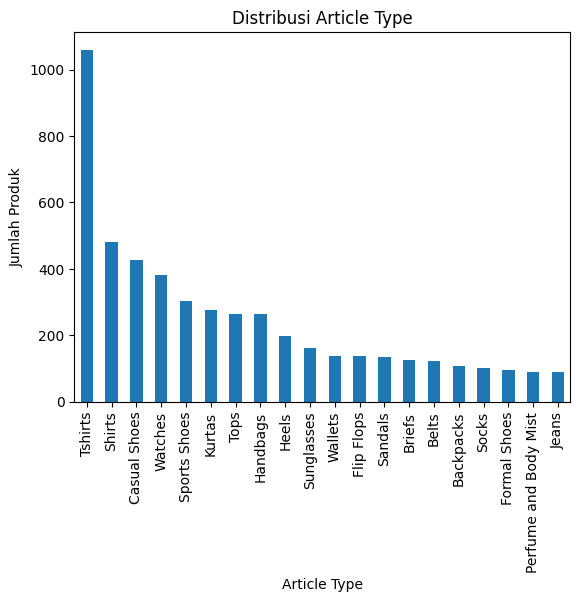

In [ ]:
plt.figure()

sample_df['articleType'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Distribusi Article Type')
plt.xlabel('Article Type')
plt.ylabel('Jumlah Produk')
plt.show()

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/project_ml_uas"
IMAGE_DIR = os.path.join(PROJECT_DIR, "images")
os.makedirs(IMAGE_DIR,exist_ok=True)

print(IMAGE_DIR)

/content/drive/MyDrive/project_ml_uas/images


In [ ]:
#Save dataset fix
sample_df.to_csv(
    os.path.join(
        PROJECT_DIR,
        "FIX_sample_df.csv"
    ),
    index=False
)

# Fungsi Download Image

In [ ]:
def download_image(row):

    filename = row["filename"]

    url = row["link"]

    save_path = os.path.join(
        IMAGE_DIR,
        filename
    )

    # biar skip kalo udah ada
    if os.path.exists(save_path):
        return "exists"

    try:

        response = requests.get(
            url,
            timeout=15
        )

        if response.status_code == 200:

            with open(
                save_path,
                "wb"
            ) as f:

                f.write(
                    response.content
                )

            return "success"

        return "failed"

    except:
        return "failed"

In [ ]:
rows = [
    row
    for _, row in sample_df.iterrows()
]

success = 0
failed = 0
exists = 0

with ThreadPoolExecutor(
    max_workers=32
) as executor:

    futures = [

        executor.submit(
            download_image,
            row
        )

        for row in rows
    ]

    for future in tqdm(
        as_completed(futures),
        total=len(futures)
    ):

        result = future.result()

        if result == "success":
            success += 1

        elif result == "failed":
            failed += 1

        elif result == "exists":
            exists += 1

print("\nDOWNLOAD PROCESS")

print("Downloaded :", success)

print("Exist :", exists)

print("Failed :", failed)

100%|██████████| 4963/4963 [00:01<00:00, 4941.13it/s]


DOWNLOAD PROCESS
Downloaded : 0
Exist : 4963
Failed : 0


## Cek Jumlah Image

In [ ]:
image_files = os.listdir(IMAGE_DIR)

print("Jumlah gambar:", len(image_files))

Jumlah gambar: 4963


In [ ]:
print("Jumlah gambar:", len(sample_df))

Jumlah gambar: 4963


In [ ]:
#Image path
sample_df["image_path"] = sample_df["filename"].apply(lambda x: os.path.join(IMAGE_DIR, x))

In [ ]:
#Filter valid
sample_df = sample_df[sample_df["image_path"].apply(os.path.exists)].copy()
sample_df.shape

(4963, 13)

In [ ]:
#Save
sample_df.to_csv(os.path.join(PROJECT_DIR, "FIXX_sample_df.csv"), index=False)

# Load Final Dataframe

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/project_ml_uas"

sample_df = pd.read_csv(os.path.join(PROJECT_DIR, "FIXX_sample_df.csv"))
print(sample_df.shape)
sample_df.head()

(4963, 13)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,filename,link,image_path
0,7120,Unisex,Accessories,Bags,Backpacks,Green,Winter,2015.0,Casual,Wildcraft Unisex Green Printed Backpack,7120.jpg,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/project_ml_uas/images/7...
1,15653,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2011.0,Casual,Belkin Unisex Simple Backpack Navy Blue Backpacks,15653.jpg,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/project_ml_uas/images/1...
2,7056,Unisex,Accessories,Bags,Backpacks,Black,Summer,2011.0,Sports,Nike Unisex Trng Max Black Backpack,7056.jpg,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/project_ml_uas/images/7...
3,4583,Unisex,Accessories,Bags,Backpacks,Grey,Winter,2015.0,Casual,Wildcraft Unisex Grey Backpack,4583.jpg,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/project_ml_uas/images/4...
4,39511,Unisex,Accessories,Bags,Backpacks,Orange,Summer,2012.0,Casual,Peter England Unisex Orange Backpack,39511.jpg,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/project_ml_uas/images/3...


In [ ]:
print(sample_df['articleType'].nunique())
print(sample_df['articleType'].value_counts().head())

20
articleType
Tshirts         1060
Shirts           482
Casual Shoes     427
Watches          381
Sports Shoes     302
Name: count, dtype: int64


In [ ]:
print(sample_df.isna().sum())

id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
productDisplayName    0
filename              0
link                  0
image_path            0
dtype: int64


## Train, Validation, Test &  Split

In [ ]:
train_df, temp_df = train_test_split(sample_df,
    test_size=0.2,
    random_state=42,
    stratify=sample_df['articleType']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['articleType']
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(3970, 13)
(496, 13)
(497, 13)


In [ ]:
print(train_df['articleType'].value_counts().head())
print(val_df['articleType'].value_counts().head())
print(test_df['articleType'].value_counts().head())

articleType
Tshirts         848
Shirts          385
Casual Shoes    341
Watches         305
Sports Shoes    242
Name: count, dtype: int64
articleType
Tshirts         106
Shirts           48
Casual Shoes     43
Watches          38
Sports Shoes     30
Name: count, dtype: int64
articleType
Tshirts         106
Shirts           49
Casual Shoes     43
Watches          38
Sports Shoes     30
Name: count, dtype: int64


In [ ]:
#savee jaga2 aja
train_df.to_csv(os.path.join(PROJECT_DIR, "train_df.csv"), index=False)
val_df.to_csv(os.path.join(PROJECT_DIR, "val_df.csv"), index=False)
test_df.to_csv(os.path.join(PROJECT_DIR, "test_df.csv"), index=False)

# Final Train-Val-Test

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
PROJECT_DIR = "/content/drive/MyDrive/project_ml_uas"

train_df = pd.read_csv(os.path.join(PROJECT_DIR, "train_df.csv"))
val_df = pd.read_csv(os.path.join(PROJECT_DIR, "val_df.csv"))
test_df = pd.read_csv(os.path.join(PROJECT_DIR, "test_df.csv"))

# CNN Model

## Image Prepocessing

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=15,

    zoom_range=0.15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

## Generator

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='articleType',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

Found 3970 validated image filenames belonging to 20 classes.


In [ ]:
val_generator = val_test_datagen.flow_from_dataframe(dataframe=val_df,
    x_col='image_path',
    y_col='articleType',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 496 validated image filenames belonging to 20 classes.


In [ ]:
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='articleType',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 497 validated image filenames belonging to 20 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Model

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.3)(x)
output = Dense(
    len(train_generator.class_indices),
    activation='softmax'
)(x)

In [ ]:
cnn_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [ ]:
cnn_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,591,060 (9.88 MB)

 Trainable params: 333,076 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Training Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/project_ml_uas/best_cnn.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - accuracy: 0.6446 - loss: 1.1775 
Epoch 1: val_loss improved from None to 0.43386, saving model to /content/drive/MyDrive/fashion_project/best_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/fashion_project/best_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 3522s 28s/step - accuracy: 0.7607 - loss: 0.7322 - val_accuracy: 0.8246 - val_loss: 0.4339 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.8434 - loss: 0.4276
Epoch 2: val_loss improved from 0.43386 to 0.36569, saving model to /content/drive/MyDrive/fashion_project/best_cnn.keras

Epoch 2: finished saving model to /content/drive/MyDrive/fashion_project/best_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 115s 919ms/step - accuracy: 0.8547 - loss: 0.4155 - val_accuracy: 0.8528 - val_loss: 0.3657 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.8763 - loss: 0.3358
Epoch 3: val_loss improved fr

## Evaluation

In [ ]:
test_loss, test_acc = cnn_model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 354s 24s/step - accuracy: 0.9074 - loss: 0.2288
Test Accuracy: 0.9074
Test Loss: 0.2288


In [ ]:
y_pred_prob_cnn = cnn_model.predict(test_generator)
y_pred_cnn = np.argmax(y_pred_prob_cnn, axis=1)
y_true_cnn = test_generator.classes

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 544ms/step


In [ ]:
correct_idx = np.where(
    y_pred_cnn == y_true_cnn
)[0]

print(len(correct_idx))

451


In [ ]:
class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))

                       precision    recall  f1-score   support

            Backpacks       1.00      0.91      0.95        11
                Belts       1.00      1.00      1.00        12
               Briefs       1.00      1.00      1.00        12
         Casual Shoes       0.86      0.74      0.80        43
           Flip Flops       0.87      1.00      0.93        13
         Formal Shoes       0.70      0.78      0.74         9
             Handbags       0.87      0.96      0.91        27
                Heels       0.76      0.80      0.78        20
                Jeans       1.00      1.00      1.00         9
               Kurtas       0.93      0.96      0.95        28
Perfume and Body Mist       1.00      0.89      0.94         9
              Sandals       0.67      0.57      0.62        14
               Shirts       0.94      0.98      0.96        49
                Socks       1.00      1.00      1.00        10
         Sports Shoes       0.77      0.90      0.83  

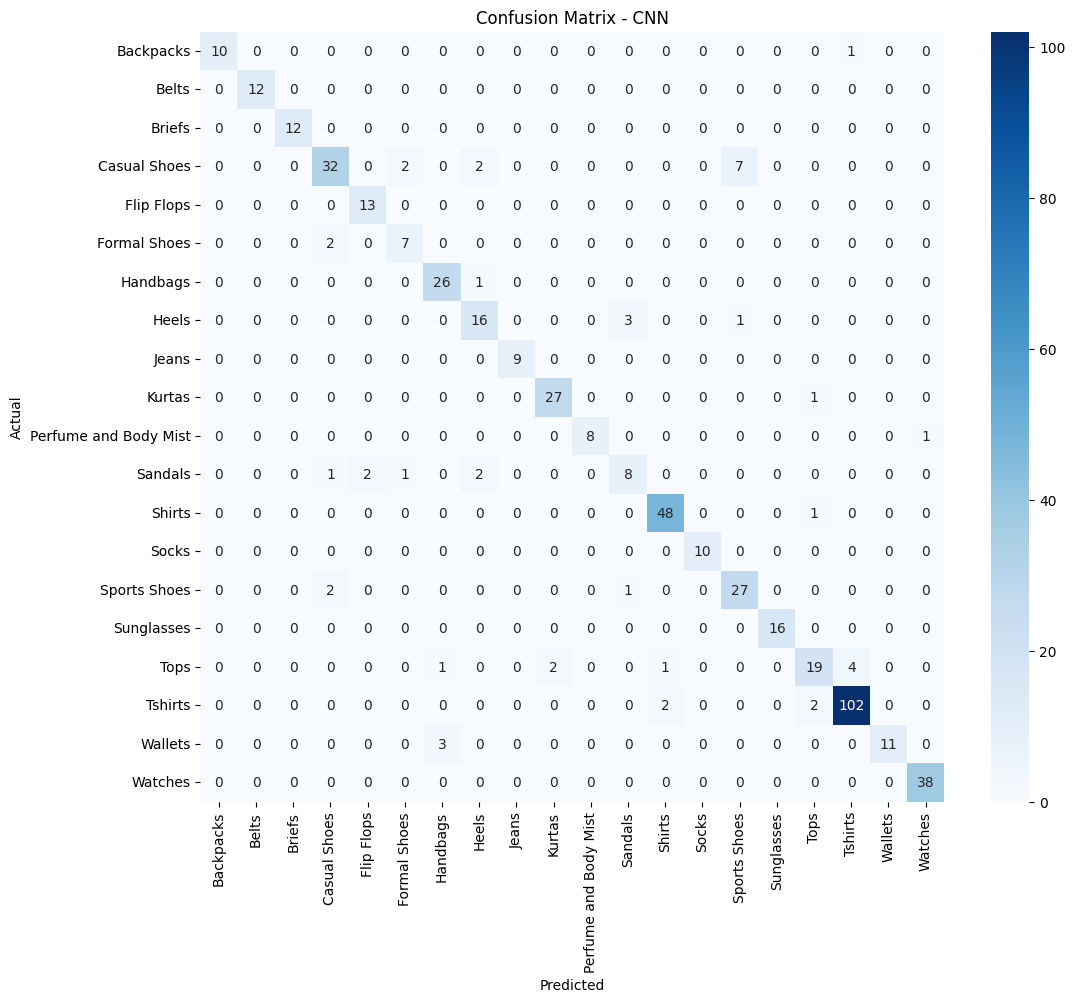

In [65]:
cm = confusion_matrix(y_true_cnn,y_pred_cnn)
plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=y_encoder.classes_,
    yticklabels=y_encoder.classes_
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CNN')
plt.show()

## Contoh Klasifikasi

In [ ]:
correct_conf = np.max(y_pred_prob_cnn, axis=1)

correct_sorted = correct_idx[
    np.argsort(
        correct_conf[correct_idx]
    )[::-1]
]

print(correct_sorted[:5])

[492 184 126 140 292]


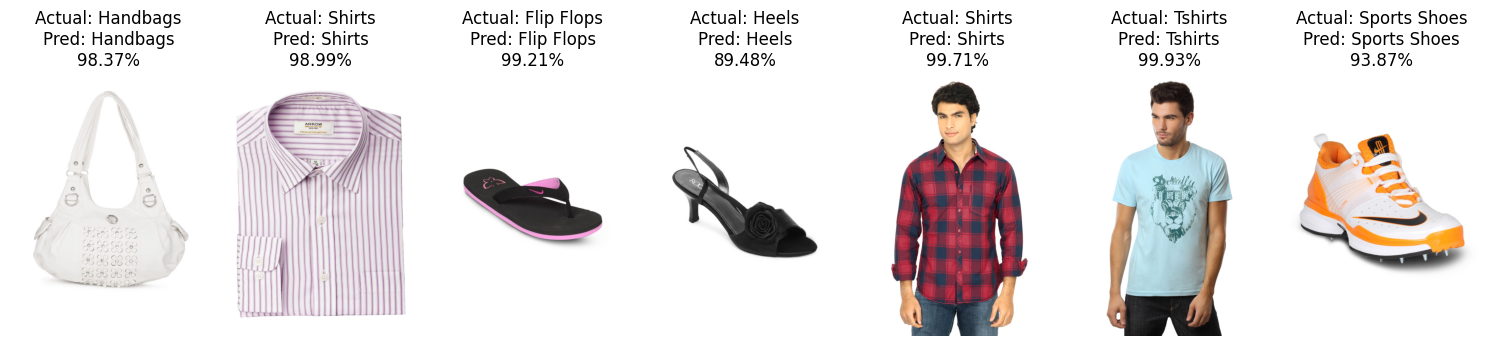

In [ ]:
class_names = list(test_generator.class_indices.keys())
random_correct = np.random.choice(correct_idx, size=7, replace=False)
plt.figure(figsize=(15,7))

for i, idx in enumerate(random_correct):
    img_path = test_df.iloc[idx]['image_path']

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    actual = class_names[y_true_cnn[idx]]
    pred = class_names[y_pred_cnn[idx]]

    confidence = np.max(y_pred_prob_cnn[idx])

    plt.subplot(1,7,i+1)
    plt.imshow(image)

    plt.title(
        f"Actual: {actual}\n"
        f"Pred: {pred}\n"
        f"{confidence:.2%}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

Yang salah terklasifikasi:

In [56]:
wrong_idx = np.where(y_pred_cnn != y_true_cnn)[0]

np.random.seed(42)
random_wrong = np.random.choice(wrong_idx, size=7, replace=False)

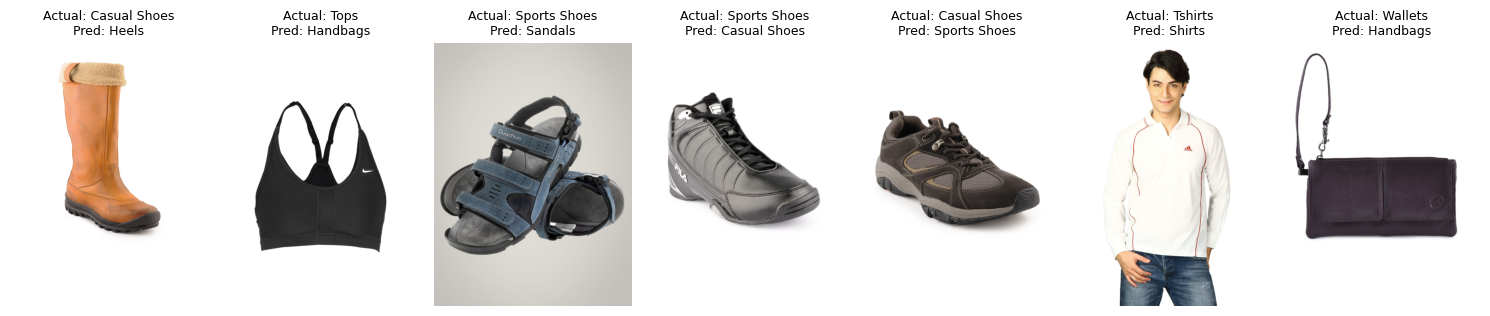

In [57]:
class_names = list(test_generator.class_indices.keys())
plt.figure(figsize=(15,5))

for i, idx in enumerate(random_wrong):

    img_path = test_df.iloc[idx]['image_path']

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    actual = class_names[y_true_cnn[idx]]
    pred = class_names[y_pred_cnn[idx]]

    confidence = np.max(y_pred_prob_cnn[idx])

    plt.subplot(1, 7, i + 1)
    plt.imshow(image)

    plt.title(
        f"Actual: {actual}\n"
        f"Pred: {pred}",
        fontsize=9
    )

    plt.xlabel("Conf: {confidence:.1%}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# MLP Model

## Features

In [10]:
X2_train = train_df[
    [
        'gender',
        'masterCategory',
        'subCategory',
        'baseColour',
        'season',
        'year',
        'usage'
    ]
]

y2_train = train_df['articleType']
print(X2_train.shape)

(3970, 7)


In [11]:
X2_val = val_df[
    [
        'gender',
        'masterCategory',
        'subCategory',
        'baseColour',
        'season',
        'year',
        'usage'
    ]
]

y2_val = val_df['articleType']
print(X2_val.shape)

(496, 7)


In [12]:
X2_test = test_df[
    [
        'gender',
        'masterCategory',
        'subCategory',
        'baseColour',
        'season',
        'year',
        'usage'
    ]
]

y2_test = test_df['articleType']
print(X2_test.shape)

(497, 7)


## OHE & Standarization

In [13]:
categorical_cols = [
    'gender',
    'masterCategory',
    'subCategory',
    'baseColour',
    'season',
    'usage'
]

numeric_cols = ['year']

In [14]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

X2_train_processed = preprocessor.fit_transform(X2_train)
X2_val_processed = preprocessor.transform(X2_val)
X2_test_processed = preprocessor.transform(X2_test)

print(X2_train_processed.shape)
print(X2_val_processed.shape)
print(X2_test_processed.shape)

(3970, 79)
(496, 79)
(497, 79)


In [15]:
y_encoder = LabelEncoder()

y2_train_encoded = y_encoder.fit_transform(y2_train)
y2_val_encoded = y_encoder.transform(y2_val)
y2_test_encoded = y_encoder.transform(y2_test)

print(len(y_encoder.classes_))
print(y_encoder.classes_)

20
['Backpacks' 'Belts' 'Briefs' 'Casual Shoes' 'Flip Flops' 'Formal Shoes'
 'Handbags' 'Heels' 'Jeans' 'Kurtas' 'Perfume and Body Mist' 'Sandals'
 'Shirts' 'Socks' 'Sports Shoes' 'Sunglasses' 'Tops' 'Tshirts' 'Wallets'
 'Watches']


In [16]:
y2_train_cat = to_categorical(y2_train_encoded)
y2_val_cat = to_categorical(y2_val_encoded)
y2_test_cat = to_categorical(y2_test_encoded)

print(y2_train_cat.shape)
print(y2_val_cat.shape)
print(y2_test_cat.shape)

(3970, 20)
(496, 20)
(497, 20)


In [17]:
type(X2_train_processed)

scipy.sparse._csr.csr_matrix

In [18]:
X2_train_processed = X2_train_processed.toarray()
X2_val_processed = X2_val_processed.toarray()
X2_test_processed = X2_test_processed.toarray()

In [19]:
print(y2_train_cat.shape)
print(y2_val_cat.shape)
print(y2_test_cat.shape)

type(X2_train_processed)

(3970, 20)
(496, 20)
(497, 20)


numpy.ndarray

In [20]:
#Save
#joblib.dump(preprocessor, os.path.join(PROJECT_DIR, "preprocessor.pkl"))

In [21]:
#joblib.dump(y_encoder, os.path.join(PROJECT_DIR, "y_encoder.pkl"))

In [22]:
preprocessor = joblib.load(os.path.join(PROJECT_DIR, "preprocessor.pkl"))
y_encoder = joblib.load(os.path.join(PROJECT_DIR, "y_encoder.pkl"))

## Model

In [ ]:
mlp_model = Sequential([
    Input(shape=(79,)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(20, activation='softmax')
])

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,420 (25.08 KB)

 Trainable params: 6,420 (25.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
history_mlp = mlp_model.fit(
    X2_train_processed,
    y2_train_cat,
    validation_data=(X2_val_processed, y2_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3418 - loss: 2.2740 - val_accuracy: 0.5423 - val_loss: 1.5446
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6549 - loss: 1.2078 - val_accuracy: 0.8165 - val_loss: 0.7940
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8149 - loss: 0.7015 - val_accuracy: 0.8871 - val_loss: 0.4867
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8451 - loss: 0.5119 - val_accuracy: 0.8891 - val_loss: 0.3782
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8657 - loss: 0.4084 - val_accuracy: 0.8931 - val_loss: 0.3259
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8688 - loss: 0.3664 - val_accuracy: 0.8931 - val_loss: 0.3007
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8798 - loss: 0.3366 - val_accuracy: 0.8952 - val_loss: 0.2893
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8715 - loss: 0.3263 - val_accuracy: 0

In [ ]:
#mlp_model.save(os.path.join(PROJECT_DIR, "best_mlp.keras"))

In [ ]:
mlp_model = load_model(os.path.join(PROJECT_DIR, "best_mlp.keras"))

## Evaluation

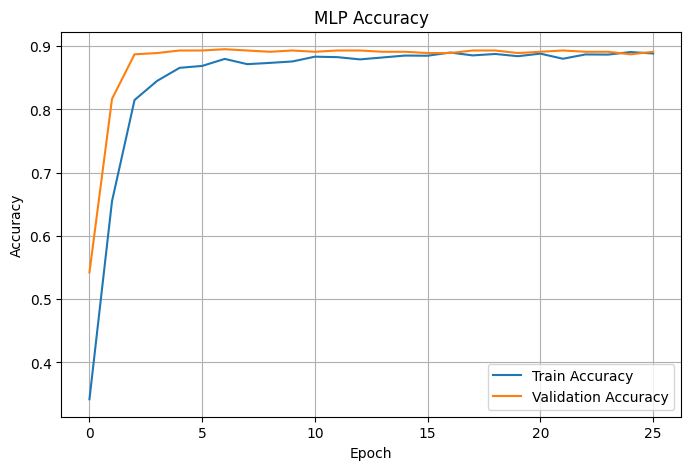

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_mlp.history['accuracy'], label='Train Accuracy')

plt.plot(history_mlp.history['val_accuracy'], label='Validation Accuracy')

plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_acc = mlp_model.evaluate(
    X2_test_processed,
    y2_test_cat,
    verbose=0
)

print("Test Accuracy :", test_acc)
print("Test Loss :", test_loss)

Test Accuracy : 0.8973842859268188
Test Loss : 0.24845677614212036


In [ ]:
y2_pred_prob = mlp_model.predict(X2_test_processed)
y2_pred = np.argmax(y2_pred_prob,axis=1)

print(classification_report(y2_test_encoded, y2_pred, target_names=y_encoder.classes_))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
                       precision    recall  f1-score   support

            Backpacks       0.85      1.00      0.92        11
                Belts       1.00      1.00      1.00        12
               Briefs       1.00      1.00      1.00        12
         Casual Shoes       0.95      0.86      0.90        43
           Flip Flops       1.00      1.00      1.00        13
         Formal Shoes       0.89      0.89      0.89         9
             Handbags       1.00      0.93      0.96        27
                Heels       0.80      1.00      0.89        20
                Jeans       1.00      1.00      1.00         9
               Kurtas       1.00      1.00      1.00        28
Perfume and Body Mist       1.00      1.00      1.00         9
              Sandals       1.00      1.00      1.00        14
               Shirts       1.00      0.37      0.54        49
                Socks       1.00      1.00      1.00        10
         Sport

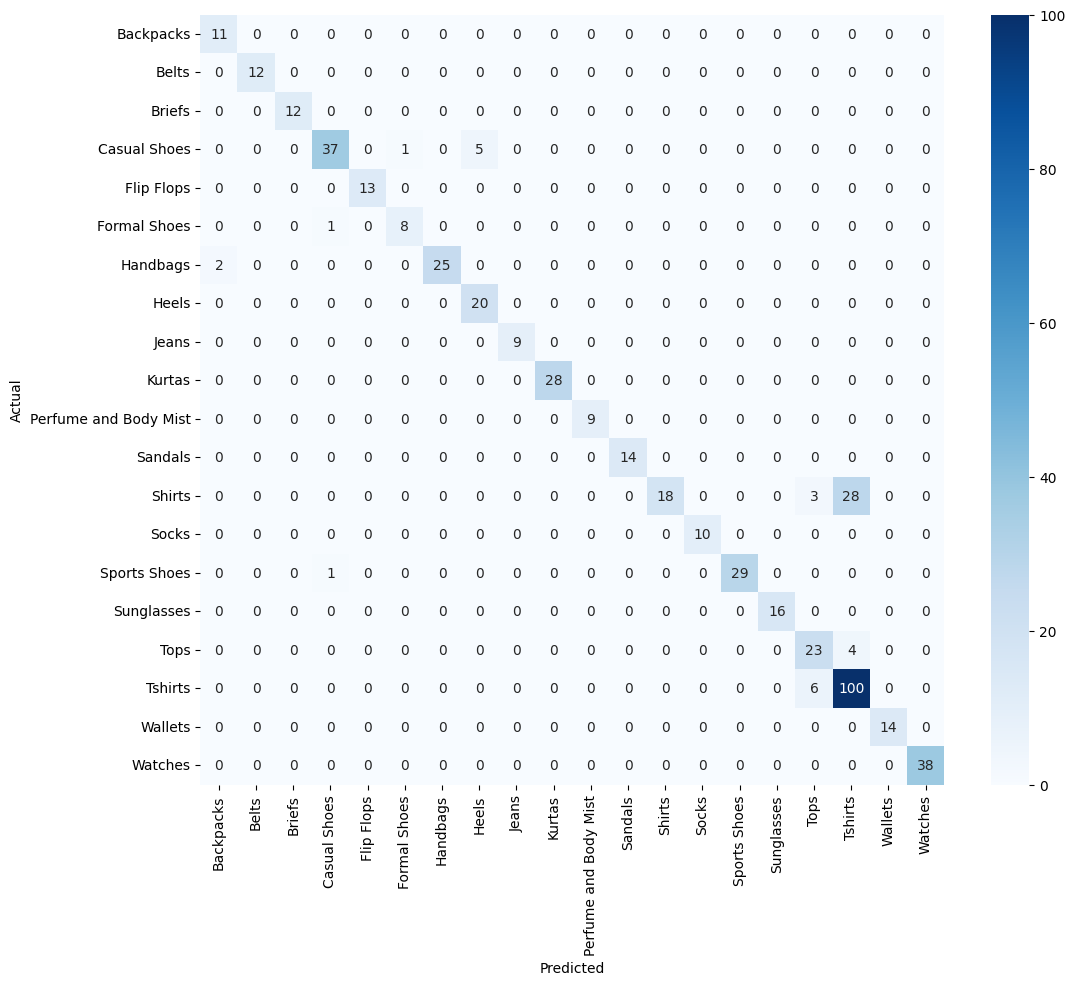

In [ ]:
cm = confusion_matrix(y2_test_encoded, y2_pred)
plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=y_encoder.classes_,
    yticklabels=y_encoder.classes_
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Fusion: CNN+MLP

## Generator

In [ ]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='articleType',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3970 validated image filenames belonging to 20 classes.


In [ ]:
val_generator = val_test_datagen.flow_from_dataframe(dataframe=val_df,
    x_col='image_path',
    y_col='articleType',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 496 validated image filenames belonging to 20 classes.


In [ ]:
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='articleType',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 497 validated image filenames belonging to 20 classes.


## Data Preparation

In [25]:
train_image_paths = train_df['image_path'].values
val_image_paths = val_df['image_path'].values
test_image_paths = test_df['image_path'].values

print(len(train_image_paths))
print(len(val_image_paths))
print(len(test_image_paths))

3970
496
497


In [33]:
IMG_SIZE = (224, 224)

def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image,channels=3)
    image = tf.image.resize(image,IMG_SIZE)
    image = image / 255.0
    return image

In [34]:
def process_sample(image_path, metadata, label):
    image = load_image(image_path)
    return ({'image_input': image,'meta_input': metadata}, label)

In [35]:
X_train_processed = X2_train_processed.astype('float32')
X_val_processed = X2_val_processed.astype('float32')
X_test_processed = X2_test_processed.astype('float32')

y_train_cat = y2_train_cat.astype('float32')
y_val_cat = y2_val_cat.astype('float32')
y_test_cat = y2_test_cat.astype('float32')

## Fusion Data

In [36]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_image_paths, X2_train_processed, y_train_cat)
)

In [37]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_image_paths, X2_val_processed, y_val_cat)
)

In [38]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_image_paths, X2_test_processed, y_test_cat)
)

In [39]:
train_dataset = train_dataset.map(process_sample, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(process_sample, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(process_sample, num_parallel_calls=tf.data.AUTOTUNE)

In [40]:
BATCH_SIZE = 32

train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [41]:
for batch in train_dataset.take(1):
    inputs, labels = batch

    print(inputs['image_input'].shape)
    print(inputs['meta_input'].shape)
    print(labels.shape)

(32, 224, 224, 3)
(32, 79)
(32, 20)


## Model

In [ ]:
image_input = Input(shape=(224, 224, 3), name='image_input')

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [ ]:
# CNN
image_features = base_model(image_input)
image_features = GlobalAveragePooling2D()(image_features)
image_features = Dense(128, activation='relu')(image_features)

In [ ]:
# MLP
meta_input = Input(shape=(79,), name='meta_input')
meta_features = Dense(64, activation='relu')(meta_input)
meta_features = Dropout(0.3)(meta_features)
meta_features = Dense(32, activation='relu')(meta_features)

In [ ]:
fusion = Concatenate()([image_features, meta_features])
fusion = Dense(128, activation='relu')(fusion)
fusion = Dropout(0.3)(fusion)

In [ ]:
output = Dense(20, activation='softmax')(fusion)

In [ ]:
fusion_model = Model(
    inputs=[image_input, meta_input],
    outputs=output
)

In [ ]:
fusion_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
fusion_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 79)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      5,120 │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dense_2[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     20,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 20)        │      2,580 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,452,340 (9.35 MB)

 Trainable params: 194,356 (759.20 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    os.path.join(PROJECT_DIR, "best_fusion.keras"),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

## Train

In [ ]:
history_fusion = fusion_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.5627 - loss: 1.4848
Epoch 1: val_loss improved from None to 0.33298, saving model to /content/drive/MyDrive/project_ml_uas/best_fusion.keras

Epoch 1: finished saving model to /content/drive/MyDrive/project_ml_uas/best_fusion.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 69s 459ms/step - accuracy: 0.7327 - loss: 0.8742 - val_accuracy: 0.8851 - val_loss: 0.3330 - learning_rate: 0.0010
Epoch 2/50
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.8955 - loss: 0.3255
Epoch 2: val_loss improved from 0.33298 to 0.21757, saving model to /content/drive/MyDrive/project_ml_uas/best_fusion.keras

Epoch 2: finished saving model to /content/drive/MyDrive/project_ml_uas/best_fusion.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 348ms/step - accuracy: 0.9083 - loss: 0.2752 - val_accuracy: 0.9335 - val_loss: 0.2176 - learning_rate: 0.0010
Epoch 3/50
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9417 - loss: 0.1872
Epoch 3: val_loss imp

In [ ]:
fusion_model.save(os.path.join(PROJECT_DIR, "best_fusionn.keras"))

In [ ]:
fusion = load_model(os.path.join(PROJECT_DIR, "best_fusion.keras"))

In [ ]:
fusion_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 79)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      5,120 │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dense_2[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     20,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 20)        │      2,580 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,841,054 (10.84 MB)

 Trainable params: 194,356 (759.20 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 388,714 (1.48 MB)

## Evaluation

In [ ]:
test_loss, test_acc = fusion_model.evaluate(test_dataset, verbose=1)

print("Test Accuracy :", test_acc)
print("Test Loss :", test_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 596ms/step - accuracy: 0.9618 - loss: 0.1440
Test Accuracy : 0.9617705941200256
Test Loss : 0.14402799308300018


In [ ]:
y_pred_prob = fusion_model.predict(test_dataset)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step


In [ ]:
print(classification_report(y_true, y_pred, target_names=y_encoder.classes_))

                       precision    recall  f1-score   support

            Backpacks       1.00      0.91      0.95        11
                Belts       1.00      1.00      1.00        12
               Briefs       1.00      1.00      1.00        12
         Casual Shoes       0.91      0.95      0.93        43
           Flip Flops       1.00      1.00      1.00        13
         Formal Shoes       0.89      0.89      0.89         9
             Handbags       0.93      1.00      0.96        27
                Heels       0.95      0.90      0.92        20
                Jeans       1.00      1.00      1.00         9
               Kurtas       1.00      1.00      1.00        28
Perfume and Body Mist       1.00      0.89      0.94         9
              Sandals       1.00      1.00      1.00        14
               Shirts       0.94      1.00      0.97        49
                Socks       1.00      1.00      1.00        10
         Sports Shoes       1.00      0.97      0.98  

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm.shape)

(20, 20)


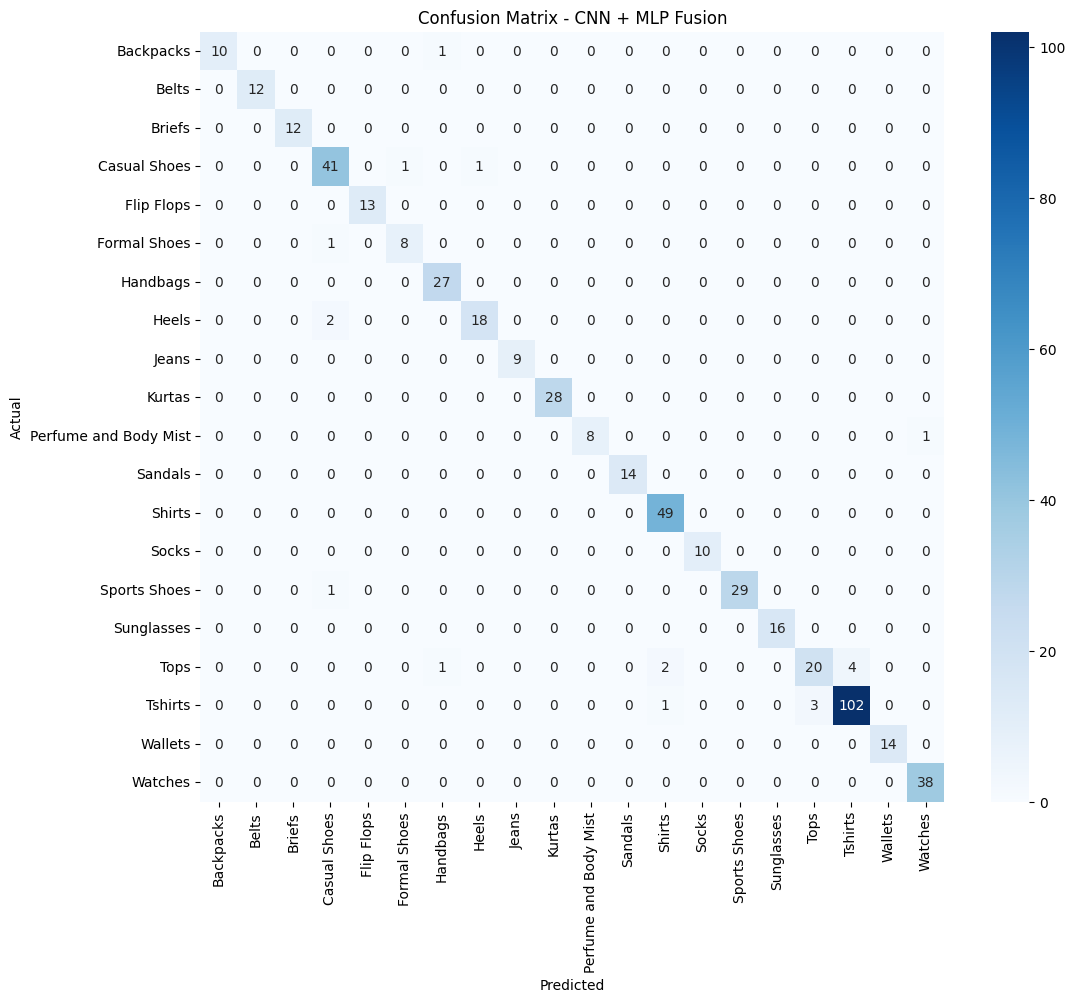

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=y_encoder.classes_,
    yticklabels=y_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN + MLP Fusion")

plt.show()

In [ ]:
fusion_results = {
    "accuracy": test_acc,
    "loss": test_loss
}

print(fusion_results)

{'accuracy': 0.9617705941200256, 'loss': 0.14402799308300018}


# Perbandingan Semua Model

## Classification Report antar model

In [45]:
#CNN
cnn_acc = accuracy_score(y_true_cnn, y_pred_cnn)
cnn_prec = precision_score(y_true_cnn, y_pred_cnn, average='weighted')
cnn_rec = recall_score(y_true_cnn, y_pred_cnn, average='weighted')
cnn_f1 = f1_score(y_true_cnn, y_pred_cnn, average='weighted')

In [46]:
#MLP
mlp_acc = accuracy_score(y2_test_encoded, y2_pred)
mlp_prec = precision_score(y2_test_encoded, y2_pred, average='weighted')
mlp_rec = recall_score(y2_test_encoded, y2_pred, average='weighted')
mlp_f1 = f1_score(y2_test_encoded, y2_pred, average='weighted')

In [47]:
#Fusion
fusion_acc = accuracy_score(y_true, y_pred)
fusion_prec = precision_score(y_true, y_pred, average='weighted')
fusion_rec = recall_score(y_true, y_pred, average='weighted')
fusion_f1 = f1_score(y_true, y_pred, average='weighted')

In [48]:
comparison_df = pd.DataFrame({
    'Model': ['CNN', 'MLP', 'CNN+MLP'],
    'Accuracy': [cnn_acc, mlp_acc, fusion_acc],
    'Precision': [cnn_prec, mlp_prec, fusion_prec],
    'Recall': [cnn_rec, mlp_rec, fusion_rec],
    'F1': [cnn_f1, mlp_f1, fusion_f1]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1
0,CNN,0.907445,0.908317,0.907445,0.905963
1,MLP,0.901408,0.918428,0.901408,0.892364
2,CNN+MLP,0.961771,0.961650,0.961771,0.961076


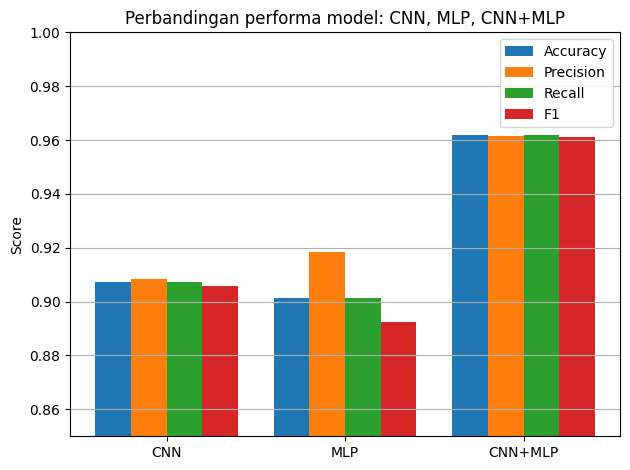

In [51]:
models = comparison_df['Model']

x = np.arange(len(models))
width = 0.2

plt.bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy')
plt.bar(x - 0.5*width, comparison_df['Precision'], width, label='Precision')
plt.bar(x + 0.5*width, comparison_df['Recall'], width, label='Recall')
plt.bar(x + 1.5*width, comparison_df['F1'], width, label='F1')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Perbandingan performa model: CNN, MLP, CNN+MLP')
plt.ylim(0.85, 1.0)

plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()

## Per kelas: CNN vs Fusion

In [58]:
cnn_report = classification_report(
    y_true_cnn,
    y_pred_cnn,
    target_names=y_encoder.classes_,
    output_dict=True
)

fusion_report = classification_report(
    y_true,
    y_pred,
    target_names=y_encoder.classes_,
    output_dict=True
)

In [59]:
cnn_f1 = pd.DataFrame(cnn_report).T.iloc[:20]
fusion_f1 = pd.DataFrame(fusion_report).T.iloc[:20]

compare_f1 = pd.DataFrame({
    'CNN': cnn_f1['f1-score'],
    'Fusion': fusion_f1['f1-score']
})

compare_f1

,CNN,Fusion
Backpacks,0.952381,0.952381
Belts,1.000000,1.000000
Briefs,1.000000,1.000000
Casual Shoes,0.800000,0.931818
Flip Flops,0.928571,1.000000
Formal Shoes,0.736842,0.888889
Handbags,0.912281,0.964286
Heels,0.780488,0.923077
Jeans,1.000000,1.000000
Kurtas,0.947368,1.000000


In [61]:
compare_f1['Improvement'] = (compare_f1['Fusion'] - compare_f1['CNN'])
compare_f1 = compare_f1.sort_values('Improvement', ascending=False)
compare_f1.head(10)

,CNN,Fusion,Improvement
Sandals,0.615385,1.000000,0.384615
Sports Shoes,0.830769,0.983051,0.152282
Formal Shoes,0.736842,0.888889,0.152047
Heels,0.780488,0.923077,0.142589
Casual Shoes,0.800000,0.931818,0.131818
Wallets,0.880000,1.000000,0.120000
Flip Flops,0.928571,1.000000,0.071429
Kurtas,0.947368,1.000000,0.052632
Handbags,0.912281,0.964286,0.052005
Tops,0.760000,0.800000,0.040000


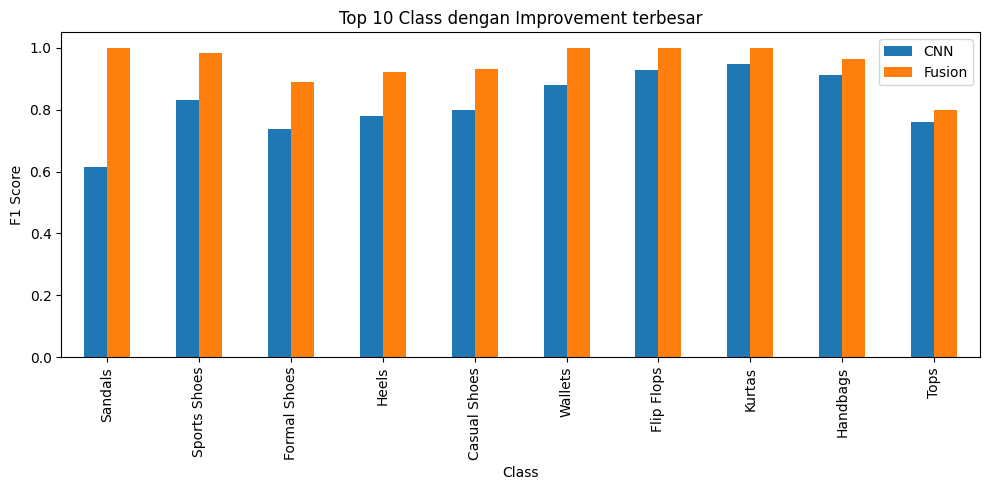

In [62]:
top10 = compare_f1.head(10)

top10[['CNN', 'Fusion']].plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Class dengan Improvement terbesar')

plt.ylabel('F1 Score')
plt.xlabel('Class')

plt.tight_layout()
plt.show()